# KCORC Summer School: TESPy Workshop
## Case Study: Double-stage R1233ZD(E) Heat Pump system -- for geothermal district heating supply

### Introduction

With the growing product range of large-scale heat pump systems, the use
of medium-deep geothermal energy has gained increasing attention over the
last years. E.g., the Energie-Wende-Garching (EWG) next to the TUM campus
has recently installed an ammonia heat pump (2 x 2.6 MW) to increase the
thermal capacity of the geothermal project.

In addition, more and more municipalities with rather low achievable
brine temperatures (e.g. 40 to 60 degC) consider using large-scale heat
pumps to upgrade the temperature level to the required district heating
supply temperatures (e.g. 90 degC). The figure below displays that the
utilization of such low- and medium-temperature resources significantly
increases the potential regions for geothermal applications. E.g. in the
northern areas of Munich.

![Figure 1: Geothermal temperature distribution in Germany](../geothermal_utilization.png)

*Figure 1: Geothermal temperature distribution in Germany (taken from Moeck et al. 2020)*

Against this background, the case study investigates a potential
R1233ZD(E) case study for a typical medium deep project. Similar to a
feasibility study for a potential geothermal heat pump project in
Schwerin (cf. Mathes et al. 2022), this workshop exercise reconstructs
that problem as a two-loop R1233zd(E) heat pump system. As shown in
Figure 2, they are fully independent heat pumps that share the
geothermal and district-heating water streams in series.

![Figure 2: Scheme of the proposed R1233ZD(E) heat pumps](../hp.svg)

*Figure 2: Scheme of the proposed R1233ZD(E) heat pumps, with connection labels b01-b05 (LT loop) and c01-c05 (HT loop)*

---

### This notebook

This notebook builds the **complete two-loop heat pump system**: the LT
loop and the HT loop, connected in series -- not through a shared
refrigerant-to-refrigerant heat exchanger, but through the geothermal and
district-heating water streams they share.

```
geo production (60 degC) -> HT-evaporator -> geo intermediate (50 degC) -> LT-evaporator -> geo injection (40 degC)

 1  -> LT compressor suction     1' -> HT compressor suction
 2  -> LT compressor discharge   2' -> HT compressor discharge
 3  -> LT condenser outlet       3' -> HT condenser outlet
 4  -> LT expansion valve outlet 4' -> HT expansion valve outlet

DH return (60 degC) -> LT-condenser -> DH intermediate (~75 degC, RESULT) -> HT-condenser -> DH supply (90 degC)
```

The **LT loop** is the cooler of the two (evaporates at 35 degC, condenses
at 80 degC), responsible for the **second (cooler) half of the geothermal
glide**, 50 -> 40 degC, and sits **first** in the district-heating line.
The **HT loop** is the hotter of the two (evaporates at 45 degC, condenses
at 95 degC), responsible for the **first (warmer) half of the geothermal
glide**, 60 -> 50 degC, and sits **last** in the district-heating line,
delivering the real 90 degC supply target.

**Design point** (constant-efficiency compressors, `eta_s = 0.75`):

| | LT loop | HT loop |
|---|---|---|
| Evaporates at | 35 degC | 45 degC |
| Condenses at | 80 degC | 95 degC |
| Geothermal segment | 50 -> 40 degC | 60 -> 50 degC |
| Pressure ratio | approx 3.58 | approx 3.70 |
| Discharge margin | approx 7.1 K | approx 5.6 K |

**What is fixed vs. a result**: the geothermal side is **fully fixed** at
all three points: production (60 degC), the intermediate split (50 degC)
and injection (40 degC). Since that split is a genuine design choice
(each loop's own share of the resource), not something left for the
solver to find, and the flow rate (100 kg/s) is given directly. On the
district-heating side, only the two real endpoints are fixed (60 degC
return, 90 degC supply); both the **intermediate temperature** (between
the two condensers) and the **mass flow rate** are left free, both
become results of the coupled system once both loops' refrigerant mass
flows are known.

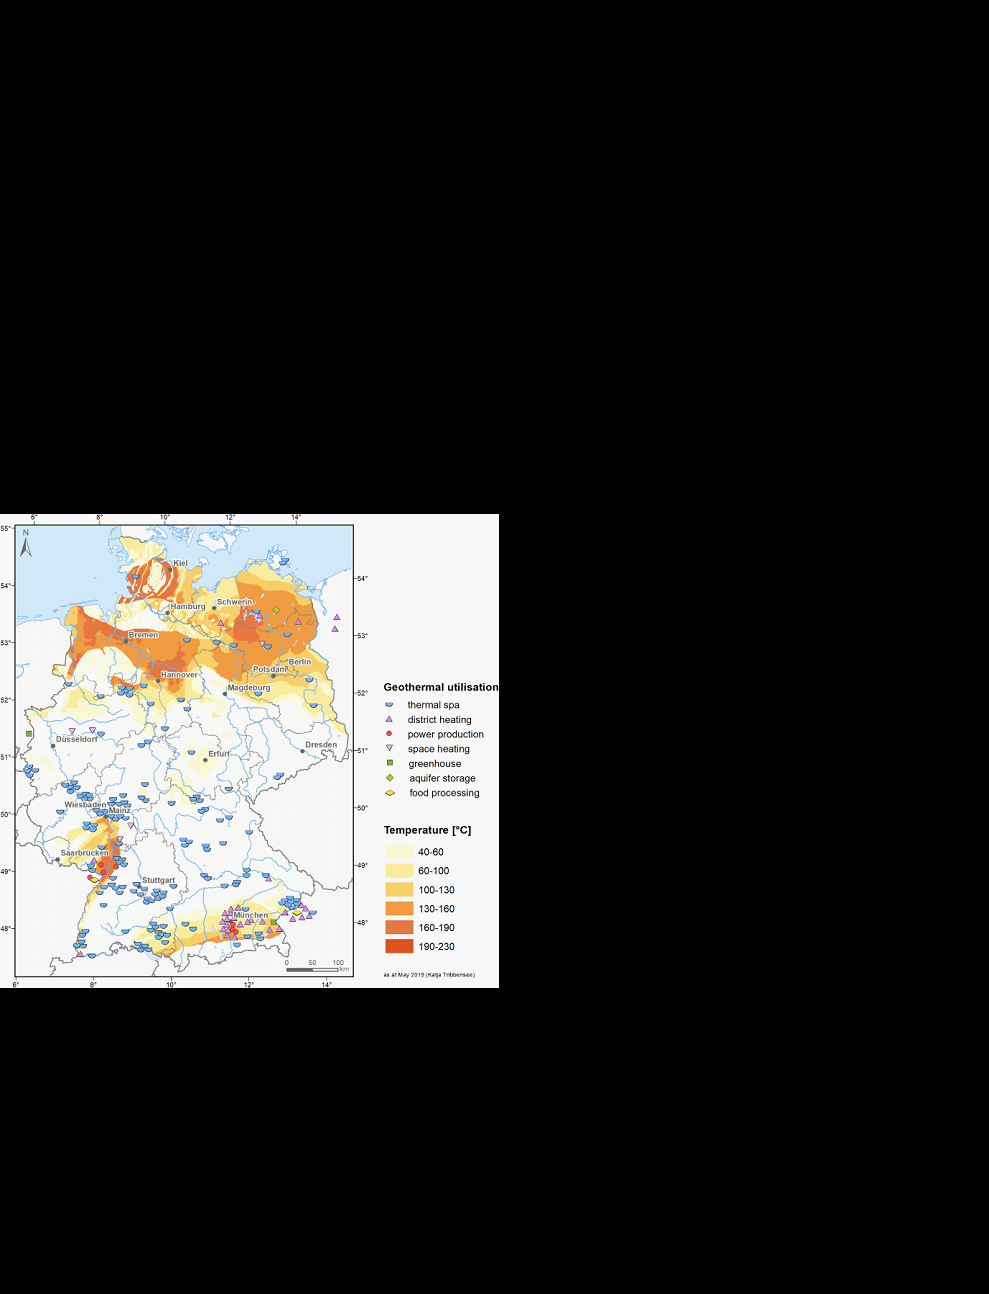
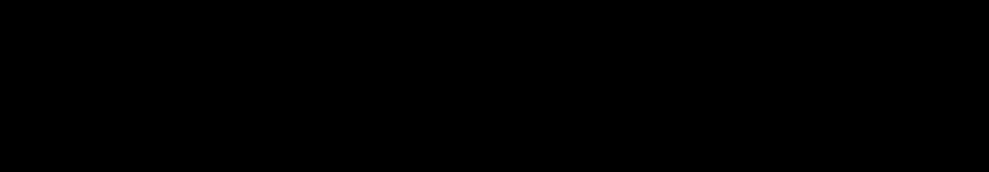
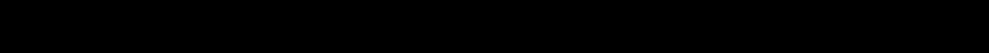
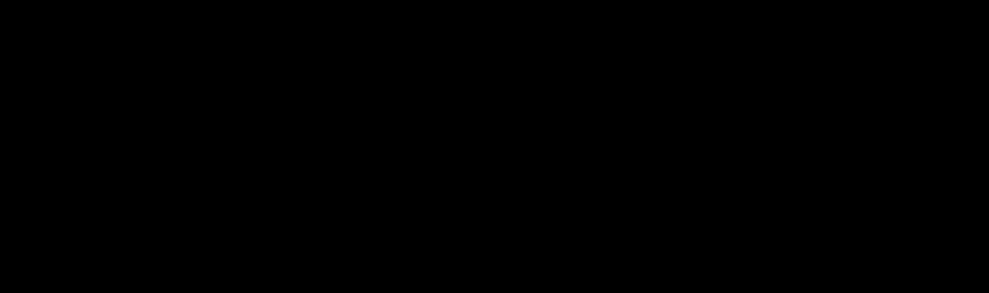
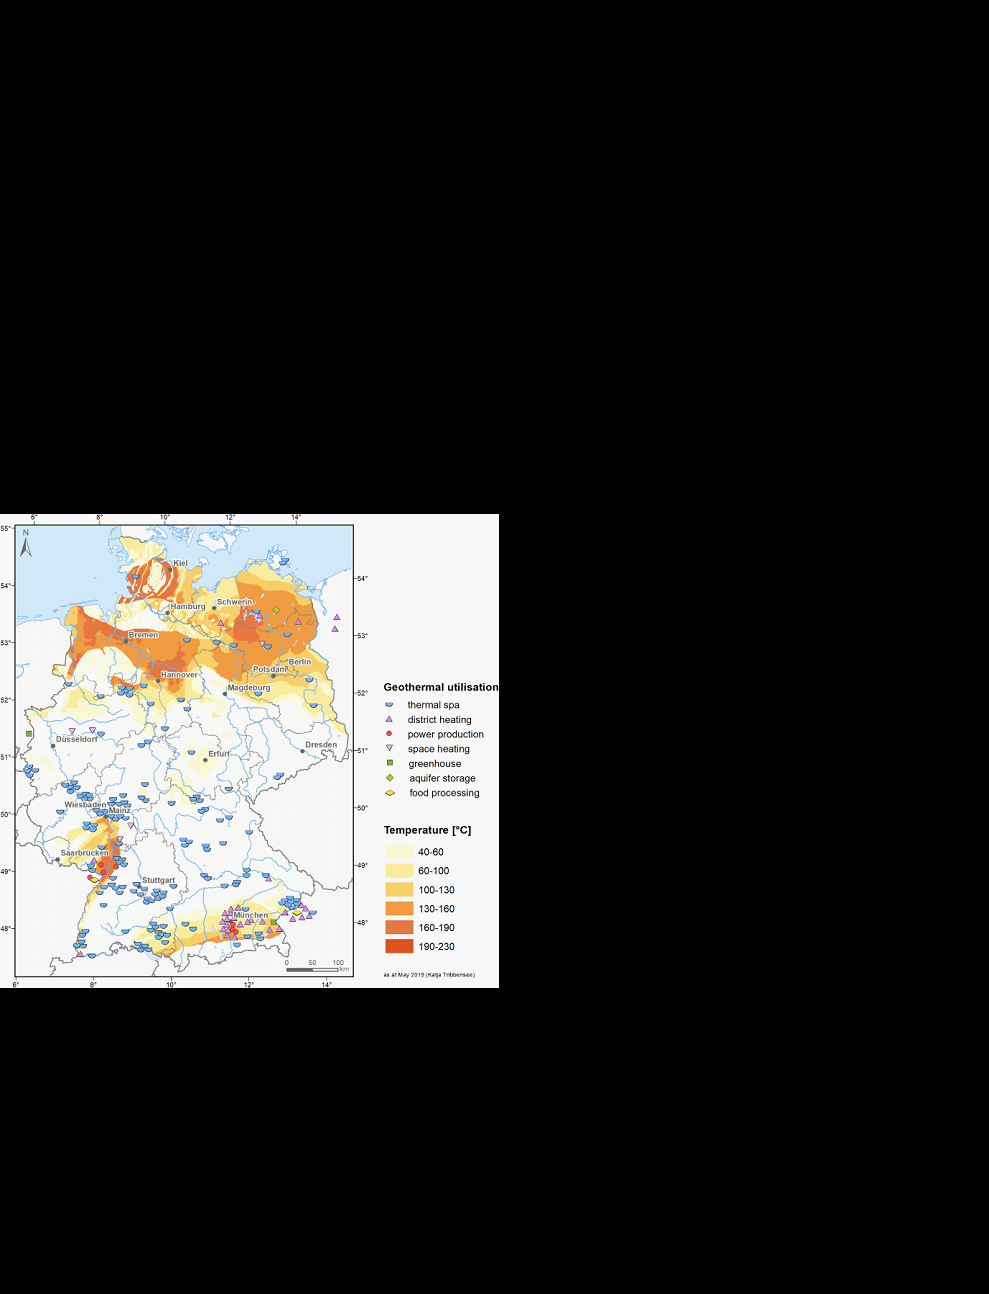

## Given:

**Table 1: Design Conditions**

| Connection | Category | Parameter | LT loop (provided) | HT loop |
|---|---|---|---|---|
| - | Working fluid | Fluid | R1233ZD(E) | R1233ZD(E) |
| b04 -> b01  /  c04 -> c01 | Evaporator | Saturation temperature | 35 degC | 45 degC |
| b01  /  c01 | | Superheat | 5 K | 5 K |
| b02 -> b03  /  c02 -> c03 | Condenser | Saturation temperature | 80 degC | 95 degC |
| b03  /  c03 | | Subcooling | 3 K | 5 K |
| b01 -> b02  /  c01 -> c02 | Compressor | Isentropic efficiency | 0.75 (constant) | 0.75 (constant) |
| - | Working fluid flow | Mass flow rate | Calculated | Calculated |

**Table 2: Geothermal Heat Source & District Heating Sink at design**

| Parameter | Value |
|---|---|
| Geothermal fluid | Water |
| Geothermal inlet temperature | 60 degC |
| Geothermal outlet temperature | 40 degC |
| Geothermal mass flow rate | 100 kg/s |
| District heating return temperature | 60 degC |
| District heating supply temperature (design target) | 90 degC |


## 1. Imports

In [1]:
from tespy.networks import Network
from tespy.components import (
    Source, Sink, Compressor, Valve, SectionedHeatExchanger, CycleCloser
)
from tespy.connections import Connection

import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI


## 2. Network and units

In [2]:
nw = Network()
nw.units.set_defaults(
    temperature='degC', pressure='bar', pressure_difference='bar',
    enthalpy='kJ/kg', mass_flow='kg/s', power='kW', heat='kW'
)


## 3. Components

In [3]:
lt_cycle_closer = CycleCloser('LT-cycle-closer')
lt_compressor = Compressor('LT-compressor')
lt_condenser = SectionedHeatExchanger('LT-condenser')
lt_expansion_valve = Valve('LT-expansion-valve')
lt_evaporator = SectionedHeatExchanger('LT-evaporator')

ht_cycle_closer = CycleCloser('HT-cycle-closer')
ht_compressor = Compressor('HT-compressor')
ht_condenser = SectionedHeatExchanger('HT-condenser')
ht_expansion_valve = Valve('HT-expansion-valve')
ht_evaporator = SectionedHeatExchanger('HT-evaporator')

geothermal_source = Source('geothermal-source')   # real: 60 degC
geothermal_sink = Sink('geothermal-sink')      # real: injection limit, 40 degC
dh_source = Source('dh-source')   # real: 60 degC
dh_sink = Sink('dh-sink')       # real: supply target, 90 degC


## 4. Connections -> LT refrigerant loop (R1233zd(E))

In [4]:
b01 = Connection(lt_cycle_closer, 'out1', lt_compressor, 'in1', label='b01')          # LT compressor suction
b02 = Connection(lt_compressor, 'out1', lt_condenser, 'in1', label='b02')   # LT compressor discharge
b03 = Connection(lt_condenser, 'out1', lt_expansion_valve, 'in1', label='b03')        # LT subcooled liquid
b04 = Connection(lt_expansion_valve, 'out1', lt_evaporator, 'in2', label='b04')       # LT evaporator inlet
b05 = Connection(lt_evaporator, 'out2', lt_cycle_closer, 'in1', label='b05')        # closes the LT cycle

nw.add_conns(b01, b02, b03, b04, b05)


## 5. Connections -> HT refrigerant loop (R1233zd(E))

In [5]:
c01 = Connection(ht_cycle_closer, 'out1', ht_compressor, 'in1', label='c01')          # HT compressor suction
c02 = Connection(ht_compressor, 'out1', ht_condenser, 'in1', label='c02')   # HT compressor discharge
c03 = Connection(ht_condenser, 'out1', ht_expansion_valve, 'in1', label='c03')        # HT subcooled liquid
c04 = Connection(ht_expansion_valve, 'out1', ht_evaporator, 'in2', label='c04')       # HT evaporator inlet
c05 = Connection(ht_evaporator, 'out2', ht_cycle_closer, 'in1', label='c05')        # closes the HT cycle

nw.add_conns(c01, c02, c03, c04, c05)


## 6. Connections -> geothermal side (production -> HT-evaporator -> LT-evaporator -> injection)

In [6]:
a01 = Connection(geothermal_source, 'out1', ht_evaporator, 'in1', label='a01')   # production -> HT-evaporator
a02 = Connection(ht_evaporator, 'out1', lt_evaporator, 'in1', label='a02')   # HT-evaporator -> LT-evaporator
a03 = Connection(lt_evaporator, 'out1', geothermal_sink, 'in1', label='a03')        # LT-evaporator -> injection

nw.add_conns(a01, a02, a03)


## 7. Connections -> district heating side (return -> LT-condenser -> HT-condenser -> supply)

In [7]:
d01 = Connection(dh_source, 'out1', lt_condenser, 'in2', label='d01')     # return -> LT-condenser
d02 = Connection(lt_condenser, 'out2', ht_condenser, 'in2', label='d02')  # LT-condenser -> HT-condenser
d03 = Connection(ht_condenser, 'out2', dh_sink, 'in1', label='d03')    # HT-condenser -> supply

nw.add_conns(d01, d02, d03)


## 8. Refrigerant-side design points (LT and HT)

In [8]:
FLUID = 'R1233zd(E)'

T_evap, T_cond, superheat, subcool = 35, 80, 5, 3          # LT loop
ht_T_evap, ht_T_cond, ht_superheat, ht_subcool = 45, 95, 5, 5   # HT loop

p_evap = PropsSI('P', 'T', T_evap + 273.15, 'Q', 1, FLUID) / 1e5
p_cond = PropsSI('P', 'T', T_cond + 273.15, 'Q', 0, FLUID) / 1e5
ht_p_evap = PropsSI('P', 'T', ht_T_evap + 273.15, 'Q', 1, FLUID) / 1e5
ht_p_cond = PropsSI('P', 'T', ht_T_cond + 273.15, 'Q', 0, FLUID) / 1e5

print(f'LT: p_evap = {p_evap:.3f} bar, p_cond = {p_cond:.3f} bar, pr = {p_cond / p_evap:.2f}')
print(f'HT: p_evap = {ht_p_evap:.3f} bar, p_cond = {ht_p_cond:.3f} bar, pr = {ht_p_cond / ht_p_evap:.2f}')


LT: p_evap = 1.837 bar, p_cond = 6.586 bar, pr = 3.58
HT: p_evap = 2.527 bar, p_cond = 9.350 bar, pr = 3.70


## 9. Parameters -> geothermal side

All three points are fixed directly: production (60 degC, real), the
LT/HT split (50 degC, a design choice), and injection (40 degC, the real
limit), all sharing the same 100 kg/s flow rate.


In [9]:
lt_evaporator.set_attr(pr1=1, pr2=1)
ht_evaporator.set_attr(pr1=1, pr2=1)

a01.set_attr(fluid={'water': 1}, T=60, p=5, m=100)   # real: geothermal production
a02.set_attr(T=50)                                    # design choice: LT/HT geothermal split
a03.set_attr(T=40)                                    # real: injection limit


## 10. Parameters -> district heating side

Only the two real endpoints are fixed (60 degC return, 90 degC supply).
The intermediate temperature and the district-heating mass flow are both
left free -- both become results of the coupled system.


In [10]:
lt_condenser.set_attr(pr1=1, pr2=1)
ht_condenser.set_attr(pr1=1, pr2=1)

d01.set_attr(fluid={'water': 1}, T=60, p=5)   # real: district heating return -- mass flow left FREE (result)
d03.set_attr(T=90)                            # real: district heating supply target


## 11. Compressors -> constant isentropic efficiency

In [11]:
lt_compressor.set_attr(eta_s=0.75)
b01.set_attr(fluid={FLUID: 1}, p=p_evap, td_dew=superheat)   # LT mass flow left FREE (result)
b02.set_attr(p=p_cond)
b03.set_attr(td_bubble=subcool)

ht_compressor.set_attr(eta_s=0.75)
c01.set_attr(fluid={FLUID: 1}, p=ht_p_evap, td_dew=ht_superheat)   # HT mass flow left FREE (result)
c02.set_attr(p=ht_p_cond)
c03.set_attr(td_bubble=ht_subcool)


## 12. Solve

In [12]:
nw.solve('design')
nw.print_results()


 block   0 | scalar          | iterations:   2 | residual: 4.12e-17 | HT-compressor.eta_s
 block   1 | scalar          | iterations:   3 | residual: 1.11e-16 | HT-evaporator.energy_balance_constraints
 block   2 | scalar          | iterations:   2 | residual: 4.19e-17 | LT-compressor.eta_s
 block   3 | scalar          | iterations:   3 | residual: 2.52e-14 | LT-evaporator.energy_balance_constraints
 block   4 | square          | iterations:   3 | residual: 2.50e-17 | HT-condenser.energy_balance_constraints, LT-condenser.energy_balance_constraints

##### RESULTS (Compressor) #####
+---------------+----------+----------+-----------+----------+
|               |        P |       pr |        dp |    eta_s |
|---------------+----------+----------+-----------+----------|
| HT-compressor | 1.10e+03 | 3.70e+00 | -6.82e+00 | 7.50e-01 |
| LT-compressor | 9.86e+02 | 3.58e+00 | -4.75e+00 | 7.50e-01 |
+---------------+----------+----------+-----------+----------+
##### RESULTS (SectionedHeatExchang

## 13. Pinch-point check (all four heat exchangers)

In [13]:
print('LT refrigerant mass flow rate:', round(b01.m.val, 3), 'kg/s')
print('HT refrigerant mass flow rate:', round(c01.m.val, 3), 'kg/s')
print('District heating mass flow rate (RESULT):', round(d01.m.val, 2), 'kg/s')
print('District heating intermediate temperature (RESULT):', round(d02.T.val, 2), 'degC')
print()
print(f"{'Component':<15}{'ttd_u [K]':>12}{'ttd_l [K]':>12}")
for hx in [lt_evaporator, lt_condenser, ht_evaporator, ht_condenser]:
    flag_u = '  <-- violation!' if hx.ttd_u.val < 0 else ''
    flag_l = '  <-- violation!' if hx.ttd_l.val < 0 else ''
    print(f"{hx.label:<15}{hx.ttd_u.val:>12.2f}{hx.ttd_l.val:>12.2f}"
          f"{flag_u if hx.ttd_u.val < 0 else flag_l}")

for name, conn, T_target in [('LT', b02, T_cond), ('HT', c02, ht_T_cond)]:
    if conn.x.val < 1:
        print()
        print(f'NOTE: {name} compressor discharge quality x = {conn.x.val:.3f} (< 1) -- wet compression.')
    else:
        print(f'{name} discharge is dry ({conn.T.val - T_target:.1f} K of superheat at the outlet).')


LT refrigerant mass flow rate: 30.514 kg/s
HT refrigerant mass flow rate: 33.064 kg/s
District heating mass flow rate (RESULT): 83.02 kg/s
District heating intermediate temperature (RESULT): 74.86 degC

Component         ttd_u [K]   ttd_l [K]
LT-evaporator         10.00        5.00
LT-condenser          12.24       17.00
HT-evaporator         10.00        5.00
HT-condenser          10.61       15.14
LT discharge is dry (7.1 K of superheat at the outlet).
HT discharge is dry (5.6 K of superheat at the outlet).


## 14. Key results

In [14]:
P_LT, P_HT = lt_compressor.P.val, ht_compressor.P.val
Q_LT_evap, Q_HT_evap = lt_evaporator.Q.val, ht_evaporator.Q.val
Q_LT_cond, Q_HT_cond = lt_condenser.Q.val, ht_condenser.Q.val

Q_useful = -Q_LT_cond + -Q_HT_cond   # kW, total heat delivered to the district-heating network
P_total = P_LT + P_HT
COP_overall = Q_useful / P_total

print('================ LT LOOP ================')
print(f'Refrigerant mass flow rate   : {b01.m.val:8.2f} kg/s')
print(f'Pressure ratio                : {b02.p.val / b01.p.val:8.2f}')
print(f'Compressor power              : {P_LT:8.1f} kW')
print(f'Evaporator / condenser duty   : {-Q_LT_evap:8.1f} / {-Q_LT_cond:8.1f} kW')
print(f'COP (LT loop only)            : {-Q_LT_cond / P_LT:8.2f}')

print()
print('================ HT LOOP ================')
print(f'Refrigerant mass flow rate   : {c01.m.val:8.2f} kg/s')
print(f'Pressure ratio                : {c02.p.val / c01.p.val:8.2f}')
print(f'Compressor power              : {P_HT:8.1f} kW')
print(f'Evaporator / condenser duty   : {-Q_HT_evap:8.1f} / {-Q_HT_cond:8.1f} kW')
print(f'COP (HT loop only)            : {-Q_HT_cond / P_HT:8.2f}')

print()
print('================ FULL SYSTEM ================')
print(f'Total compressor power        : {P_total:8.1f} kW')
print(f'Total heat delivered           : {Q_useful:8.1f} kW')
print(f'Overall COP                    : {COP_overall:8.2f}')


================ LT LOOP ================
Refrigerant mass flow rate   :    30.51 kg/s
Pressure ratio                :     3.58
Compressor power              :    985.6 kW
Evaporator / condenser duty   :   4179.3 /   5164.9 kW
COP (LT loop only)            :     5.24

================ HT LOOP ================
Refrigerant mass flow rate   :    33.06 kg/s
Pressure ratio                :     3.70
Compressor power              :   1095.8 kW
Evaporator / condenser duty   :   4182.1 /   5278.0 kW
COP (HT loop only)            :     4.82

================ FULL SYSTEM ================
Total compressor power        :   2081.5 kW
Total heat delivered           :  10442.8 kW
Overall COP                    :     5.02


## 15. T-s diagram (both loops)

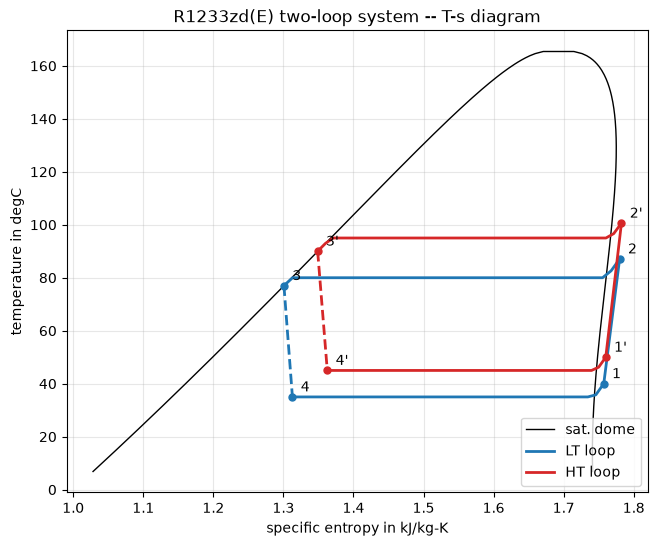

In [15]:
def conn_Ts(conn):
    p_Pa = conn.p.val * 1e5
    h_Jkg = conn.h.val * 1e3
    T = PropsSI('T', 'P', p_Pa, 'H', h_Jkg, FLUID) - 273.15
    s = PropsSI('S', 'P', p_Pa, 'H', h_Jkg, FLUID) / 1e3
    return T, s


def isobar_Ts(p_bar, h1_kJkg, h2_kJkg, n=40):
    p_Pa = p_bar * 1e5
    hs = np.linspace(h1_kJkg, h2_kJkg, n) * 1e3
    T = PropsSI('T', 'P', p_Pa, 'H', hs, FLUID) - 273.15
    s = PropsSI('S', 'P', p_Pa, 'H', hs, FLUID) / 1e3
    return T, s


T_crit = PropsSI('Tcrit', FLUID)
T_dome = np.linspace(280, T_crit - 0.3, 200)
sf = PropsSI('S', 'T', T_dome, 'Q', 0, FLUID) / 1e3
sg = PropsSI('S', 'T', T_dome, 'Q', 1, FLUID) / 1e3
T_dome_C = T_dome - 273.15

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(np.concatenate([sf, sg[::-1]]), np.concatenate([T_dome_C, T_dome_C[::-1]]),
        'k-', lw=1, label='sat. dome')

for label_suffix, states, color in [('', {'1': b01, '2': b02, '3': b03, '4': b04}, 'tab:blue'),
                                     ("'", {'1': c01, '2': c02, '3': c03, '4': c04}, 'tab:red')]:
    pts = {k: conn_Ts(v) for k, v in states.items()}
    ax.plot([pts['1'][1], pts['2'][1]], [pts['1'][0], pts['2'][0]], '-', color=color, lw=2)
    T23, s23 = isobar_Ts(states['2'].p.val, states['2'].h.val, states['3'].h.val)
    ax.plot(s23, T23, '-', color=color, lw=2)
    ax.plot([pts['3'][1], pts['4'][1]], [pts['3'][0], pts['4'][0]], '--', color=color, lw=2)
    T41, s41 = isobar_Ts(states['4'].p.val, states['4'].h.val, states['1'].h.val)
    ax.plot(s41, T41, '-', color=color, lw=2, label=f'{"LT" if label_suffix=="" else "HT"} loop')
    for k, (T, s) in pts.items():
        ax.plot(s, T, 'o', color=color, ms=5)
        ax.annotate(k + label_suffix, (s, T), textcoords='offset points', xytext=(6, 4))

ax.set_xlabel('specific entropy in kJ/kg-K')
ax.set_ylabel('temperature in degC')
ax.set_title('R1233zd(E) two-loop system -- T-s diagram')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()


## 16. T-Q diagrams (all four heat exchangers)

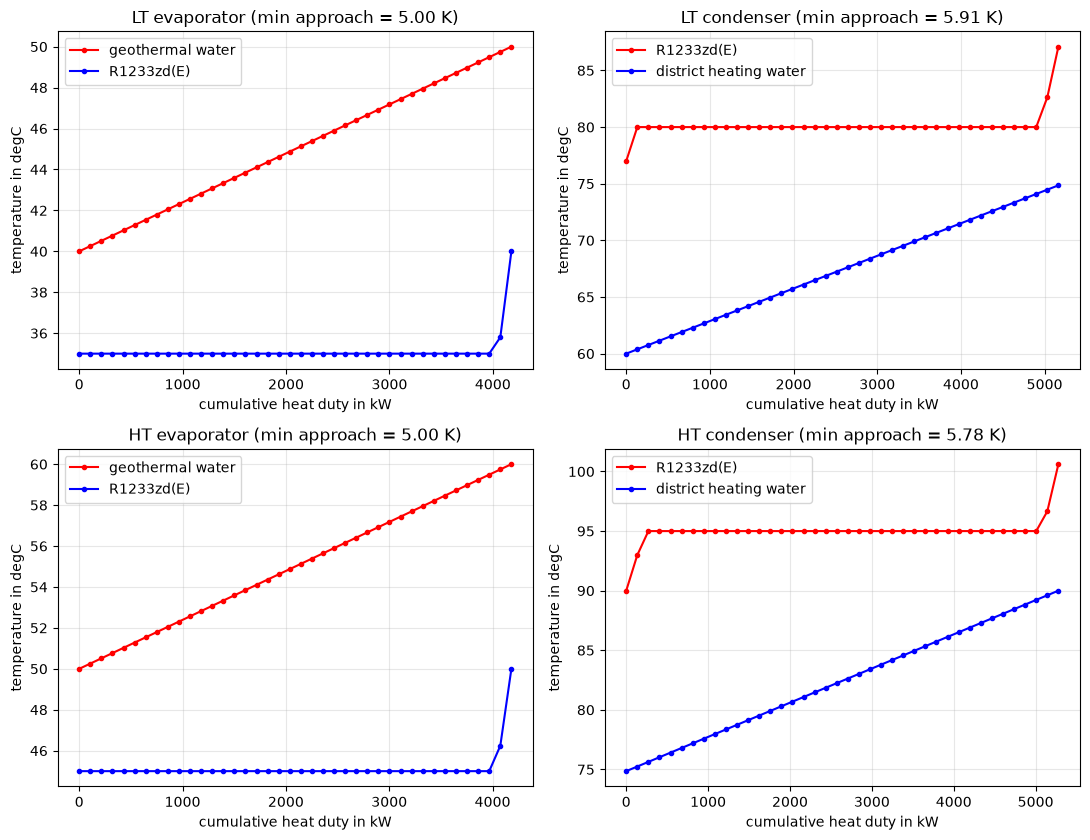

In [16]:
def counter_current_profile(m_hot, fluid_hot, p_hot_in_bar, p_hot_out_bar, h_hot_in, h_hot_out,
                             m_cold, fluid_cold, p_cold_in_bar, p_cold_out_bar, h_cold_in, h_cold_out,
                             n=40):
    Q_total = m_cold * (h_cold_out - h_cold_in)  # kW
    Q = np.linspace(0, Q_total, n)
    h_cold = h_cold_in + Q / m_cold
    h_hot = h_hot_out + Q / m_hot
    p_cold = np.linspace(p_cold_in_bar, p_cold_out_bar, n) * 1e5
    p_hot = np.linspace(p_hot_out_bar, p_hot_in_bar, n) * 1e5
    T_cold = PropsSI('T', 'P', p_cold, 'H', h_cold * 1e3, fluid_cold) - 273.15
    T_hot = PropsSI('T', 'P', p_hot, 'H', h_hot * 1e3, fluid_hot) - 273.15
    return Q, T_hot, T_cold


fig, axs = plt.subplots(2, 2, figsize=(11, 8.5))

Q, Th, Tc = counter_current_profile(
    a02.m.val, 'water', a02.p.val, a03.p.val, a02.h.val, a03.h.val,
    b04.m.val, FLUID, b04.p.val, b01.p.val, b04.h.val, b01.h.val)
axs[0, 0].plot(Q, Th, 'r-o', ms=3, label='geothermal water')
axs[0, 0].plot(Q, Tc, 'b-o', ms=3, label=FLUID)
axs[0, 0].set_title(f'LT evaporator (min approach = {(Th - Tc).min():.2f} K)')

Q, Th, Tc = counter_current_profile(
    b02.m.val, FLUID, b02.p.val, b03.p.val, b02.h.val, b03.h.val,
    d01.m.val, 'water', d01.p.val, d02.p.val, d01.h.val, d02.h.val)
axs[0, 1].plot(Q, Th, 'r-o', ms=3, label=FLUID)
axs[0, 1].plot(Q, Tc, 'b-o', ms=3, label='district heating water')
axs[0, 1].set_title(f'LT condenser (min approach = {(Th - Tc).min():.2f} K)')

Q, Th, Tc = counter_current_profile(
    a01.m.val, 'water', a01.p.val, a02.p.val, a01.h.val, a02.h.val,
    c04.m.val, FLUID, c04.p.val, c01.p.val, c04.h.val, c01.h.val)
axs[1, 0].plot(Q, Th, 'r-o', ms=3, label='geothermal water')
axs[1, 0].plot(Q, Tc, 'b-o', ms=3, label=FLUID)
axs[1, 0].set_title(f'HT evaporator (min approach = {(Th - Tc).min():.2f} K)')

Q, Th, Tc = counter_current_profile(
    c02.m.val, FLUID, c02.p.val, c03.p.val, c02.h.val, c03.h.val,
    d02.m.val, 'water', d02.p.val, d03.p.val, d02.h.val, d03.h.val)
axs[1, 1].plot(Q, Th, 'r-o', ms=3, label=FLUID)
axs[1, 1].plot(Q, Tc, 'b-o', ms=3, label='district heating water')
axs[1, 1].set_title(f'HT condenser (min approach = {(Th - Tc).min():.2f} K)')

for ax in axs.flat:
    ax.set_xlabel('cumulative heat duty in kW')
    ax.set_ylabel('temperature in degC')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
